# 00 – Exploratory Data Analysis
**ICS472 – Natural Language Processing**  
**Team:** Mohammed Al Sheqaih · Abdulrhman Ammar

Goals of this notebook:
- Verify dataset integrity (image counts, missing files, label alignment)
- Visualise sample check images with ground-truth bounding boxes
- Inspect courtesy and legal amount label distributions
- Build and save the vocabularies used by Parts B and C

## 1. Imports & Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()) + '/codebase')  # make utils importable

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from collections import Counter

import utils
from utils import (
    TRAIN_IMAGES, TEST_IMAGES, TRAIN_BBOX, TEST_BBOX,
    TRAIN_CA, TRAIN_LA, TEST_CA, TEST_LA, ARTIFACTS,
    parse_bbox, parse_courtesy_amounts, parse_legal_amounts,
    build_vocab, load_image, crop_region
)

plt.rcParams['figure.dpi'] = 120

## 2. Dataset Integrity Check

In [2]:
train_imgs  = sorted(TRAIN_IMAGES.glob('*.tif'))
test_imgs   = sorted(TEST_IMAGES.glob('*.tif'))
train_bboxes = sorted(TRAIN_BBOX.glob('*.txt'))
test_bboxes  = sorted(TEST_BBOX.glob('*.txt'))

print(f'Train images  : {len(train_imgs)}')
print(f'Train bbox files: {len(train_bboxes)}')
print(f'Test  images  : {len(test_imgs)}')
print(f'Test  bbox files: {len(test_bboxes)}')


train_img_stems  = {p.stem for p in train_imgs}
train_bbox_stems = {p.stem for p in train_bboxes}
missing_bbox = train_img_stems - train_bbox_stems
print(f'\nTrain images missing bbox: {sorted(missing_bbox)}')

Train images  : 1800
Train bbox files: 1799
Test  images  : 600
Test  bbox files: 600

Train images missing bbox: ['ac00048']


In [3]:

all_lines_2  = all(len(parse_bbox(p)) == 2 for p in train_bboxes)
print(f'All train bbox files have exactly 2 annotations: {all_lines_2}')


class_counts = Counter()
for p in train_bboxes:
    for cls, *_ in parse_bbox(p):
        class_counts[cls] += 1
print(f'Class distribution: {dict(class_counts)}  (0=legal, 1=courtesy)')

All train bbox files have exactly 2 annotations: True
Class distribution: {1: 1799, 0: 1799}  (0=legal, 1=courtesy)


## 3. Sample Image Visualisation with Bounding Boxes

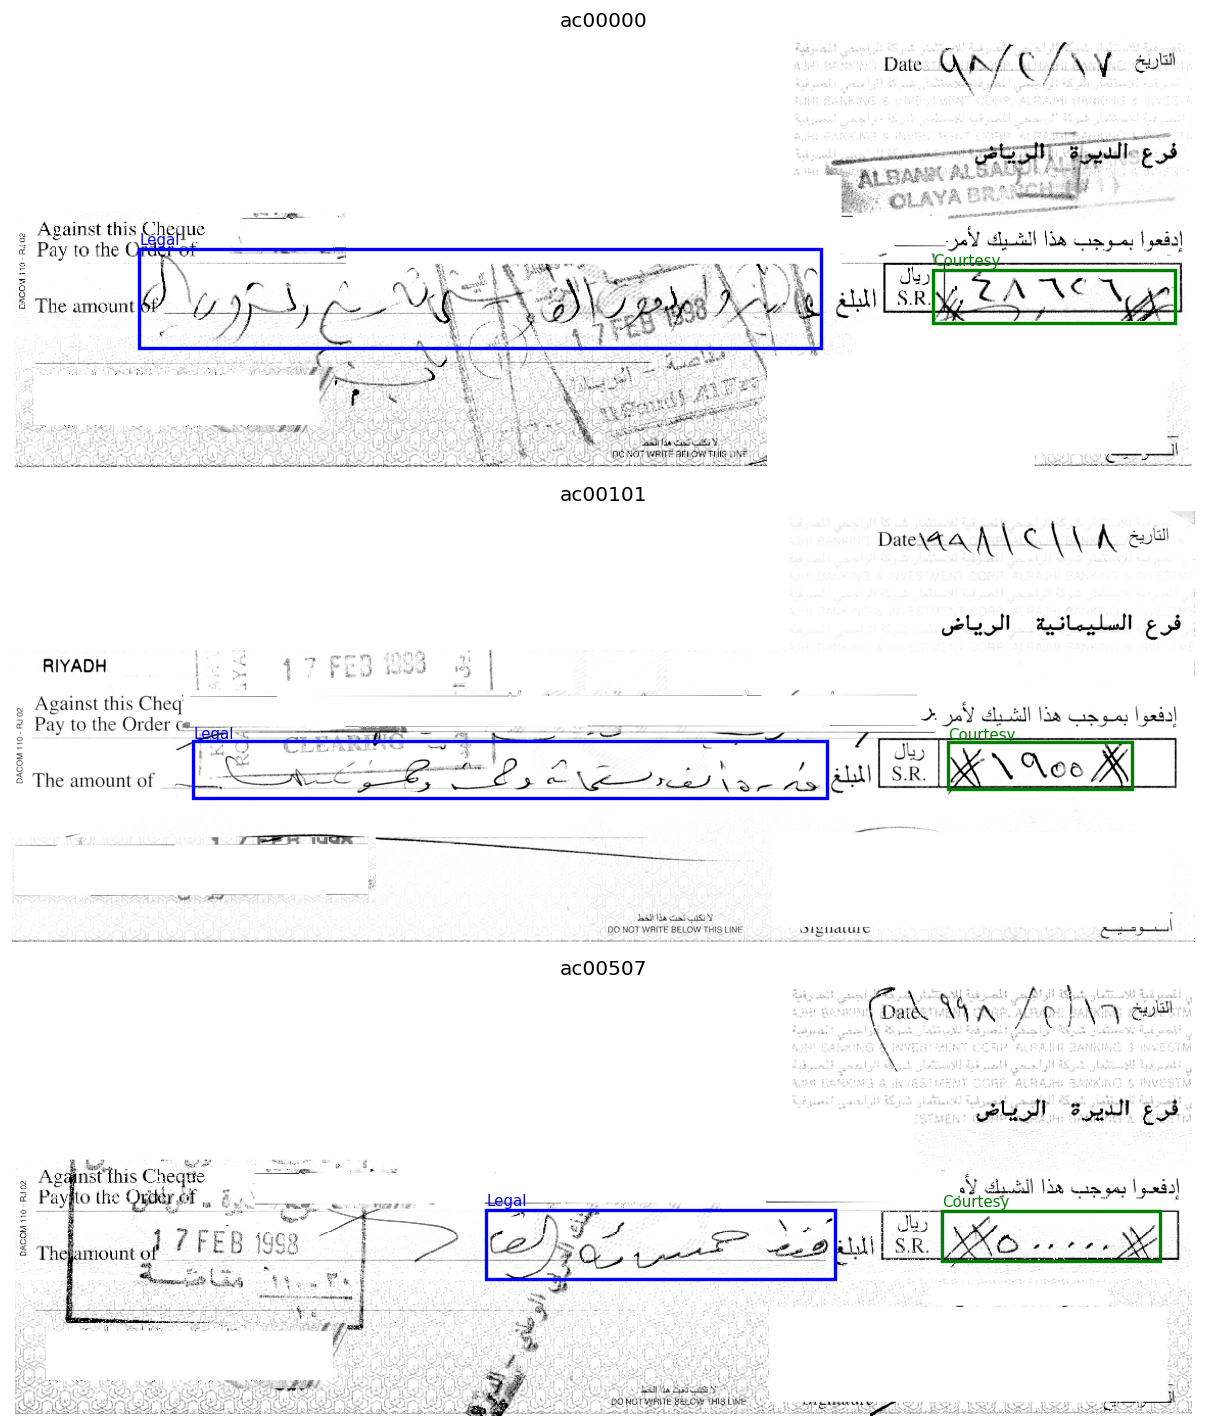

In [4]:
CLASS_COLORS = {0: 'blue', 1: 'green'}  # 0=legal (blue), 1=courtesy (green)
CLASS_NAMES  = {0: 'Legal', 1: 'Courtesy'}

def show_check(img_path, bbox_path, ax=None):
    img = Image.open(img_path)
    W, H = img.size
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img, cmap='gray')
    for cls, cx, cy, w, h in parse_bbox(bbox_path):
        x1 = (cx - w/2) * W
        y1 = (cy - h/2) * H
        rect = patches.Rectangle(
            (x1, y1), w*W, h*H,
            linewidth=2, edgecolor=CLASS_COLORS[cls], facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, CLASS_NAMES[cls], color=CLASS_COLORS[cls], fontsize=9)
    ax.axis('off')
    ax.set_title(Path(img_path).stem)

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
samples = [0, 100, 500]
for ax, idx in zip(axes, samples):
    img_path  = train_imgs[idx]
    bbox_path = TRAIN_BBOX / (img_path.stem + '.txt')
    if bbox_path.exists():
        show_check(img_path, bbox_path, ax=ax)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'sample_checks.png', bbox_inches='tight')
plt.show()

## 4. Bounding Box Size Distribution

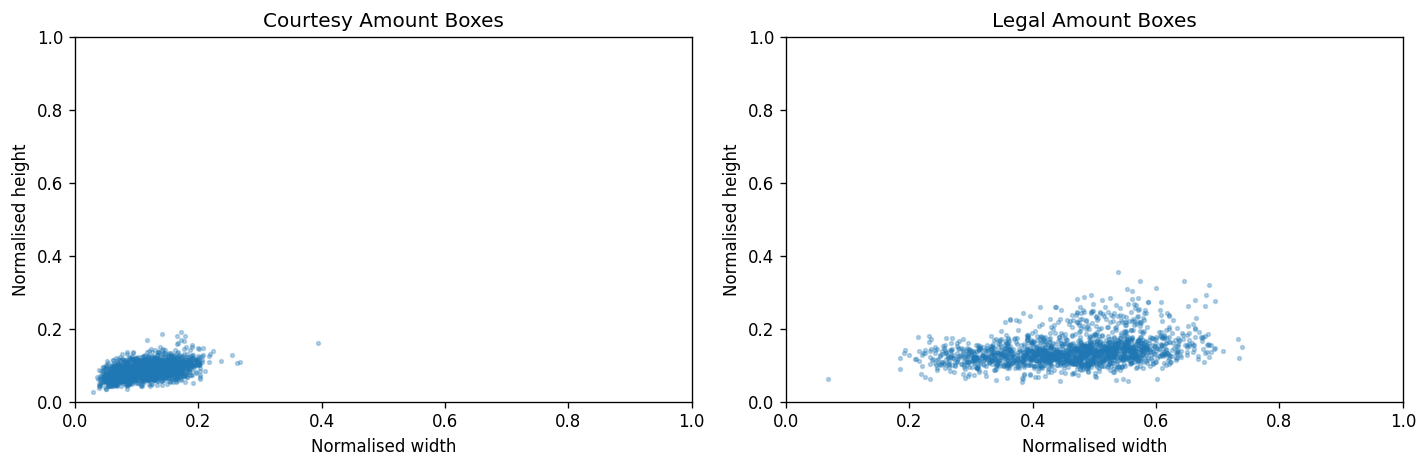

Courtesy box — avg w: 0.119, avg h: 0.088
Legal box    — avg w: 0.463, avg h: 0.141


In [5]:
ca_widths, ca_heights = [], []
la_widths, la_heights = [], []

for p in train_bboxes:
    for cls, cx, cy, w, h in parse_bbox(p):
        if cls == 1:  # courtesy
            ca_widths.append(w); ca_heights.append(h)
        else:         # legal
            la_widths.append(w); la_heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, widths, heights, title in zip(
    axes,
    [ca_widths, la_widths],
    [ca_heights, la_heights],
    ['Courtesy Amount Boxes', 'Legal Amount Boxes']
):
    ax.scatter(widths, heights, alpha=0.3, s=5)
    ax.set_xlabel('Normalised width')
    ax.set_ylabel('Normalised height')
    ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'bbox_distribution.png', bbox_inches='tight')
plt.show()

print(f'Courtesy box — avg w: {np.mean(ca_widths):.3f}, avg h: {np.mean(ca_heights):.3f}')
print(f'Legal box    — avg w: {np.mean(la_widths):.3f}, avg h: {np.mean(la_heights):.3f}')

## 5. Courtesy Amount Labels

In [6]:
train_ca_labels = parse_courtesy_amounts(TRAIN_CA)
test_ca_labels  = parse_courtesy_amounts(TEST_CA)
print(f'Train courtesy samples: {len(train_ca_labels)}')
print(f'Test  courtesy samples: {len(test_ca_labels)}')


for fname, tokens in list(train_ca_labels.items())[:5]:
    inner = [t for t in tokens if t != '<BOS/EOS>']
    print(f'  {fname}  →  {inner}')

Train courtesy samples: 1738
Test  courtesy samples: 600
  Cac00000.tif  →  ['4', '8', '6', '2', '6']
  Cac00001.tif  →  ['1', '3', '5', '0']
  Cac00002.tif  →  ['1', '5', '0', '0']
  Cac00003.tif  →  ['2', '4', '1', '5']
  Cac00004.tif  →  ['4', '5', '0', '0']


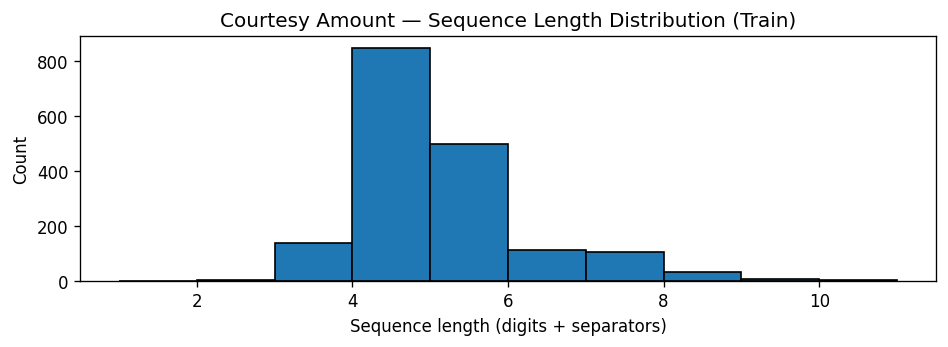

Min: 2, Max: 10, Avg: 4.6


In [7]:

train_ca_lens = [len([t for t in v if t != '<BOS/EOS>']) for v in train_ca_labels.values()]

plt.figure(figsize=(8, 3))
plt.hist(train_ca_lens, bins=range(1, max(train_ca_lens)+2), edgecolor='black')
plt.xlabel('Sequence length (digits + separators)')
plt.ylabel('Count')
plt.title('Courtesy Amount — Sequence Length Distribution (Train)')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'ca_length_dist.png', bbox_inches='tight')
plt.show()
print(f'Min: {min(train_ca_lens)}, Max: {max(train_ca_lens)}, Avg: {np.mean(train_ca_lens):.1f}')

## 6. Legal Amount Labels

In [8]:
train_la_labels = parse_legal_amounts(TRAIN_LA)
test_la_labels  = parse_legal_amounts(TEST_LA)
print(f'Train legal samples: {len(train_la_labels)}')
print(f'Test  legal samples: {len(test_la_labels)}')

for fname, tokens in list(train_la_labels.items())[:5]:
    print(f'  {fname}  →  {" ".join(tokens)}')

Train legal samples: 1799
Test  legal samples: 600
  Lac00000.tif  →  ثمانيه و اربع و ن أ لف و ستمائ ة و سته و عشر و ن ر يا ل
  Lac00001.tif  →  أ لف و ثلاثمائ ة و خمس و ن ر يا ل فقط لا غير
  Lac00002.tif  →  فقط أ لف و خمسمائه ر يا ل لا غير
  Lac00003.tif  →  ألف ا ن و أربعمائ ة و خمس عشر ر يا ل لا غير
  Lac00004.tif  →  فقط اربع ة آ لا ف و خمسمائ ة ر يا ل لا غير


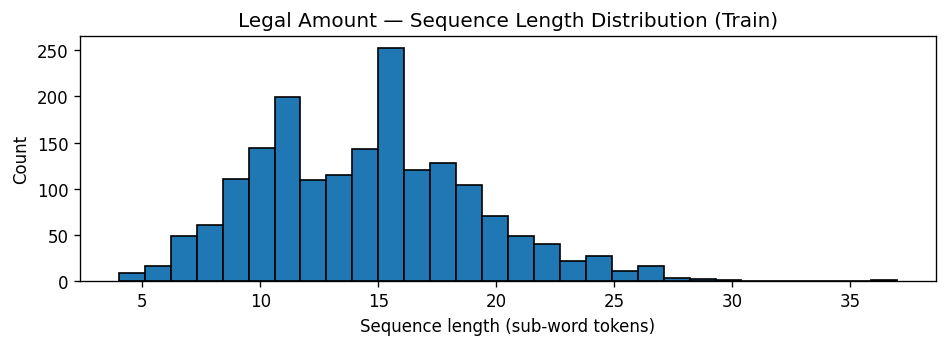

Min: 4, Max: 37, Avg: 14.4


In [9]:
# Legal sequence length distribution
train_la_lens = [len(v) for v in train_la_labels.values()]

plt.figure(figsize=(8, 3))
plt.hist(train_la_lens, bins=30, edgecolor='black')
plt.xlabel('Sequence length (sub-word tokens)')
plt.ylabel('Count')
plt.title('Legal Amount — Sequence Length Distribution (Train)')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'la_length_dist.png', bbox_inches='tight')
plt.show()
print(f'Min: {min(train_la_lens)}, Max: {max(train_la_lens)}, Avg: {np.mean(train_la_lens):.1f}')

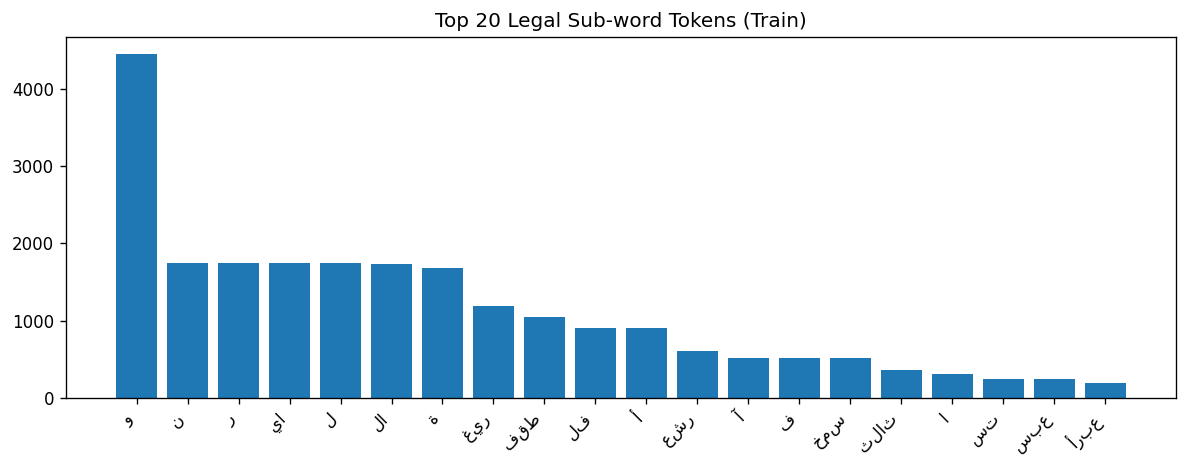

In [10]:

token_freq = Counter(t for tokens in train_la_labels.values() for t in tokens)
top20 = token_freq.most_common(20)
labels_plot, counts = zip(*top20)

plt.figure(figsize=(10, 4))
plt.bar(range(len(counts)), counts)
plt.xticks(range(len(counts)), labels_plot, rotation=45, ha='right')
plt.title('Top 20 Legal Sub-word Tokens (Train)')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'la_token_freq.png', bbox_inches='tight')
plt.show()

## 7. Sample Crops (Courtesy & Legal)

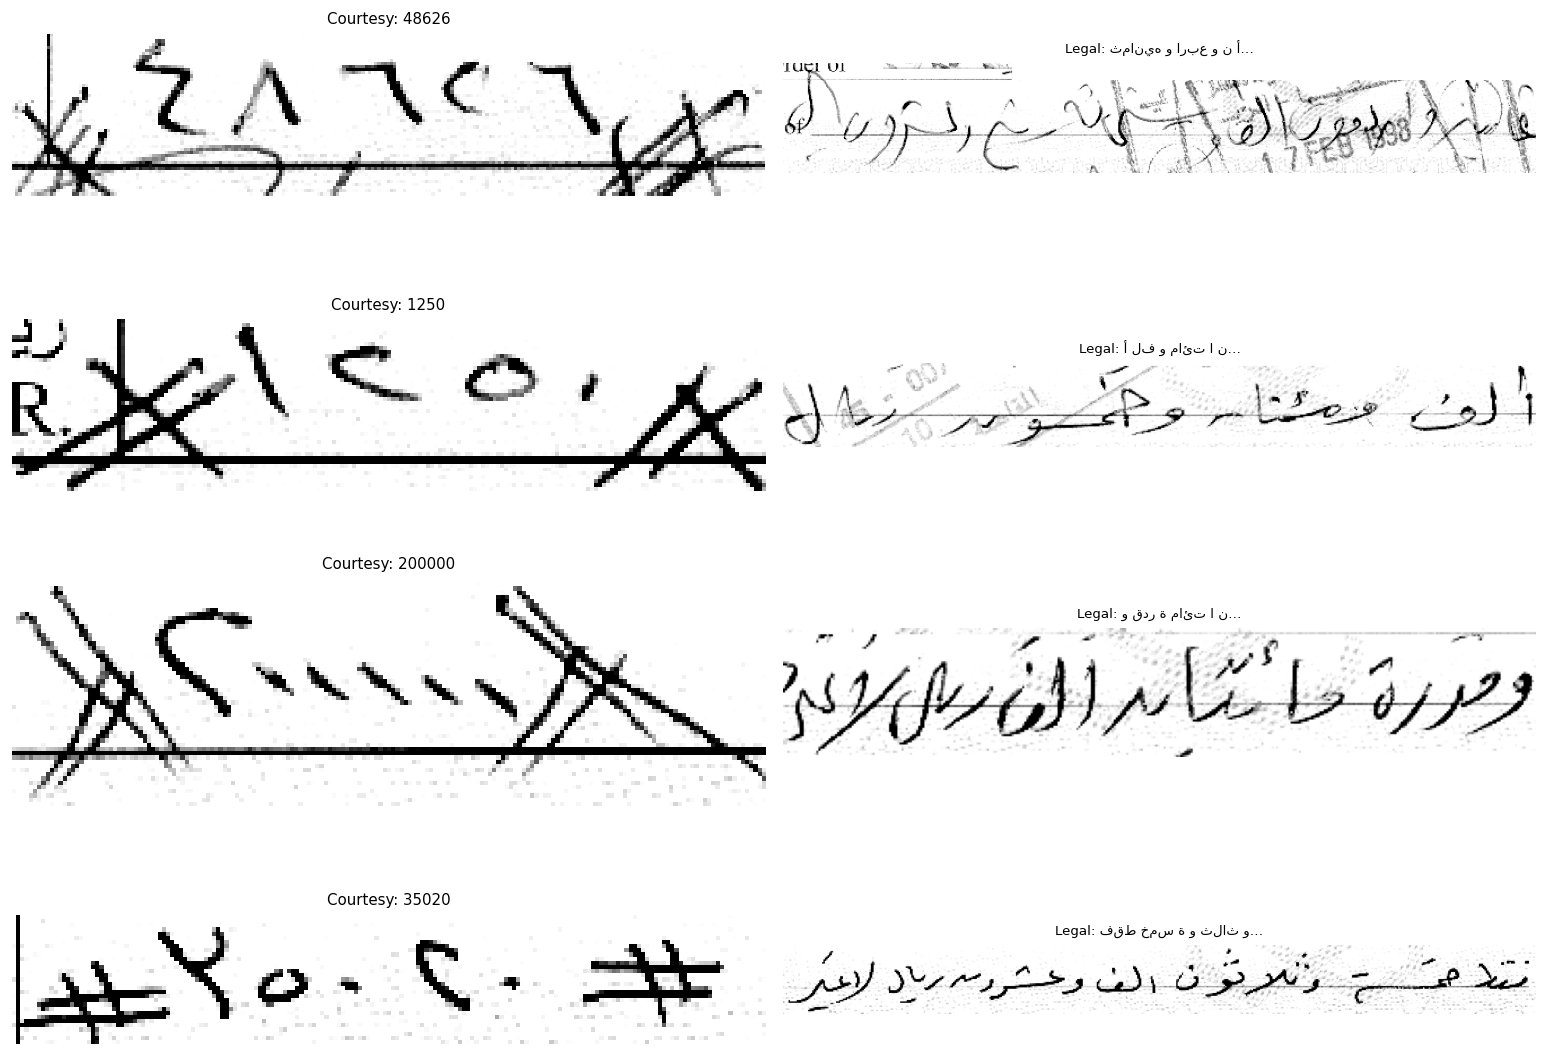

In [11]:
def get_crops(img_path, bbox_path):
    img = load_image(img_path)
    crops = {}
    for cls, cx, cy, w, h in parse_bbox(bbox_path):
        crops['courtesy' if cls == 1 else 'legal'] = crop_region(img, cx, cy, w, h)
    return crops

fig, axes = plt.subplots(4, 2, figsize=(13, 10))
sample_indices = [0, 10, 50, 200]
for row, idx in enumerate(sample_indices):
    img_path  = train_imgs[idx]
    bbox_path = TRAIN_BBOX / (img_path.stem + '.txt')
    if not bbox_path.exists():
        continue
    crops = get_crops(img_path, bbox_path)
    for col, key in enumerate(['courtesy', 'legal']):
        ax = axes[row][col]
        if key in crops:
            ax.imshow(crops[key], cmap='gray')
            # get label
            ca_key = 'C' + img_path.stem + '.tif'
            la_key = 'L' + img_path.stem + '.tif'
            if key == 'courtesy' and ca_key in train_ca_labels:
                inner = [t for t in train_ca_labels[ca_key] if t != '<BOS/EOS>']
                ax.set_title(f'Courtesy: {"".join(str(t) for t in inner)}', fontsize=9)
            elif key == 'legal' and la_key in train_la_labels:
                ax.set_title(f'Legal: {" ".join(train_la_labels[la_key][:6])}…', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'sample_crops.png', bbox_inches='tight')
plt.show()

## 8. Build & Save Vocabularies

In [12]:
# ── Courtesy vocab (train + test union, strip BOS/EOS) ──
ca_all_tokens = [
    [t for t in tokens if t != '<BOS/EOS>']
    for tokens in list(train_ca_labels.values()) + list(test_ca_labels.values())
]
ca_vocab, ca_t2i, ca_i2t = build_vocab(ca_all_tokens)
print(f'Courtesy vocab ({len(ca_vocab)} tokens): {ca_vocab}')

# ── Legal vocab (train + test union) ──
la_all_tokens = list(train_la_labels.values()) + list(test_la_labels.values())
la_vocab, la_t2i, la_i2t = build_vocab(la_all_tokens)
print(f'Legal vocab size: {len(la_vocab)} tokens')

# parts B and C load these files instead of rebuilding
with open(ARTIFACTS / 'ca_vocab.json', 'w', encoding='utf-8') as f:
    json.dump({'vocab': ca_vocab, 't2i': ca_t2i, 'i2t': {str(k): v for k,v in ca_i2t.items()}}, f, ensure_ascii=False, indent=2)

with open(ARTIFACTS / 'la_vocab.json', 'w', encoding='utf-8') as f:
    json.dump({'vocab': la_vocab, 't2i': la_t2i, 'i2t': {str(k): v for k,v in la_i2t.items()}}, f, ensure_ascii=False, indent=2)

print('\nVocabularies saved to artifacts/')

Courtesy vocab (13 tokens): ['<blank>', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '<SEP>']
Legal vocab size: 288 tokens

Vocabularies saved to artifacts/


## 9. Summary

| Item | Value |
|------|-------|
| Train images | 1,800 |
| Train bbox annotations | 1,799 (ac00048 missing) |
| Test images | 600 |
| Courtesy vocab size | — |
| Legal vocab size | — |
| Max courtesy seq len | 10 |
| Max legal seq len | 29 |

→ Update the table above after running all cells.

**Findings:**
- `ac00048` has no bounding box annotation — excluded from training.
- Courtesy token `11` (test-only) and `'/'` (train-only) both represent the fractional separator (riyals / halalas); unified as `<SEP>` in the vocabulary.
- Legal sub-word vocabulary is fully covered when train + test labels are combined — no OOV tokens at inference time.
- All bbox files contain exactly 2 annotations (class 0 = legal, class 1 = courtesy) with no corrupt entries.